In [ ]:
import torch
print(torch.cuda.is_available())


True


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

base_path = "/content/drive/MyDrive/mtech"
print(os.listdir(base_path))


['Test-20260213T111402Z-1-001.zip', 'Validation-20260213T111425Z-1-001.zip', 'Training-20260213T113205Z-1-001.zip']


In [ ]:
import zipfile
import os

base_path = "/content/drive/MyDrive/mtech"
extract_path = "/content/hcc_dataset"

os.makedirs(extract_path, exist_ok=True)

for file in os.listdir(base_path):
    if file.endswith(".zip"):
        with zipfile.ZipFile(os.path.join(base_path, file), 'r') as zip_ref:
            zip_ref.extractall(extract_path)

print("Extraction complete")


Extraction complete


In [ ]:
print(os.listdir(extract_path))

['Training', 'Validation', 'Test']


In [ ]:
train_path = "/content/hcc_dataset/Training"
print(os.listdir(train_path))


['grade2', 'grade1', 'grade3', 'grade0']


In [ ]:
!pip install timm

In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader
import timm


In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [ ]:
train_path = "/content/hcc_dataset/Training"
val_path = "/content/hcc_dataset/Validation"

train_dataset = datasets.ImageFolder(train_path, transform=transform)
val_dataset = datasets.ImageFolder(val_path, transform=transform)

print("Classes:", train_dataset.classes)


Classes: ['grade0', 'grade1', 'grade2', 'grade3']


In [ ]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

In [ ]:
model = timm.create_model(
    'vit_base_patch16_224',
    pretrained=True,
    num_classes=4
)

model = model.cuda()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

In [ ]:
for param in model.parameters():
    param.requires_grad = False

for param in model.head.parameters():
    param.requires_grad = True


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.head.parameters(), lr=0.001)


In [ ]:
epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images = images.cuda()
        labels = labels.cuda()

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader)}")


Epoch 1, Loss: 0.47816244191490115
Epoch 2, Loss: 0.21722238273359834
Epoch 3, Loss: 0.1708029409055598
Epoch 4, Loss: 0.14334160452708603
Epoch 5, Loss: 0.1328794507542625


In [ ]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images = images.cuda()
        labels = labels.cuda()

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Validation Accuracy:", 100 * correct / total)


Validation Accuracy: 93.92857142857143


In [ ]:
print(len(train_dataset))

2549


In [ ]:
from collections import Counter

print(Counter(train_dataset.targets))


Counter({2: 670, 3: 661, 1: 639, 0: 579})


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in val_loader:
        images = images.cuda()
        labels = labels.cuda()
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))


Confusion Matrix:
 [[70  0  0  0]
 [ 0 73  7  0]
 [ 0 10 70  0]
 [ 0  0  0 50]]

Classification Report:

              precision    recall  f1-score   support

      grade0       1.00      1.00      1.00        70
      grade1       0.88      0.91      0.90        80
      grade2       0.91      0.88      0.89        80
      grade3       1.00      1.00      1.00        50

    accuracy                           0.94       280
   macro avg       0.95      0.95      0.95       280
weighted avg       0.94      0.94      0.94       280



In [ ]:
for name, param in model.named_parameters():
    if "blocks.10" in name or "blocks.11" in name:
        param.requires_grad = True


In [ ]:
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)


In [ ]:
epochs = 10

for epoch in range(epochs):

    # ----- TRAIN -----
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.cuda()
        labels = labels.cuda()

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = 100 * correct / total
    train_loss = running_loss / len(train_loader)


    # ----- VALIDATION -----
    model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.cuda()
            labels = labels.cuda()

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_acc = 100 * val_correct / val_total

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {train_loss:.4f} "
          f"Train Acc: {train_acc:.2f}% "
          f"Val Acc: {val_acc:.2f}%")


Epoch [1/10] Train Loss: 0.2195 Train Acc: 91.92% Val Acc: 94.29%
Epoch [2/10] Train Loss: 0.1181 Train Acc: 95.25% Val Acc: 93.93%
Epoch [3/10] Train Loss: 0.0484 Train Acc: 97.80% Val Acc: 93.93%
Epoch [4/10] Train Loss: 0.0417 Train Acc: 98.51% Val Acc: 94.29%
Epoch [5/10] Train Loss: 0.0366 Train Acc: 98.86% Val Acc: 94.29%
Epoch [6/10] Train Loss: 0.0503 Train Acc: 98.51% Val Acc: 91.43%
Epoch [7/10] Train Loss: 0.0595 Train Acc: 97.92% Val Acc: 93.93%
Epoch [8/10] Train Loss: 0.0115 Train Acc: 99.69% Val Acc: 95.36%
Epoch [9/10] Train Loss: 0.0048 Train Acc: 99.80% Val Acc: 95.71%
Epoch [10/10] Train Loss: 0.0258 Train Acc: 99.33% Val Acc: 94.29%


In [ ]:
import os
print(os.listdir("/content"))


['.config', 'hcc_dataset', 'drive', 'sample_data']


In [ ]:
torch.save(model.state_dict(), "/content/drive/MyDrive/best_vit_hcc.pth")
print("Model saved successfully to Drive")


Model saved successfully to Drive


In [ ]:
import os
print(os.listdir("/content/drive/MyDrive"))


['Colab Notebooks', 'mtech', 'best_vit_hcc.pth']


In [ ]:
model.load_state_dict(torch.load("/content/drive/MyDrive/best_vit_hcc.pth"))
model.eval()
print("Model loaded successfully")


Model loaded successfully


In [ ]:
test_path = "/content/hcc_dataset/Test"

test_dataset = datasets.ImageFolder(test_path, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print("Test size:", len(test_dataset))


Test size: 280


In [ ]:
model.eval()
correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.cuda()
        labels = labels.cuda()

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Test Accuracy:", 100 * correct / total)


Test Accuracy: 92.85714285714286


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=test_dataset.classes))


Confusion Matrix:
 [[70  0  0  0]
 [ 0 72  8  0]
 [ 1 11 68  0]
 [ 0  0  0 50]]

Classification Report:

              precision    recall  f1-score   support

      grade0       0.99      1.00      0.99        70
      grade1       0.87      0.90      0.88        80
      grade2       0.89      0.85      0.87        80
      grade3       1.00      1.00      1.00        50

    accuracy                           0.93       280
   macro avg       0.94      0.94      0.94       280
weighted avg       0.93      0.93      0.93       280



In [ ]:
from sklearn.metrics import roc_auc_score
import torch.nn.functional as F
import numpy as np

model.eval()

all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.cuda()
        outputs = model(images)
        probs = F.softmax(outputs, dim=1)

        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')
print("Overall ROC-AUC:", auc)


Overall ROC-AUC: 0.9908671875


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.cuda()
        labels = labels.cuda()

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)


In [ ]:
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:\n")
print(cm)


Confusion Matrix:

[[70  0  0  0]
 [ 0 75  5  0]
 [ 0 11 69  0]
 [ 0  0  1 49]]


In [ ]:
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=test_dataset.classes))



Classification Report:

              precision    recall  f1-score   support

      grade0       1.00      1.00      1.00        70
      grade1       0.87      0.94      0.90        80
      grade2       0.92      0.86      0.89        80
      grade3       1.00      0.98      0.99        50

    accuracy                           0.94       280
   macro avg       0.95      0.94      0.95       280
weighted avg       0.94      0.94      0.94       280



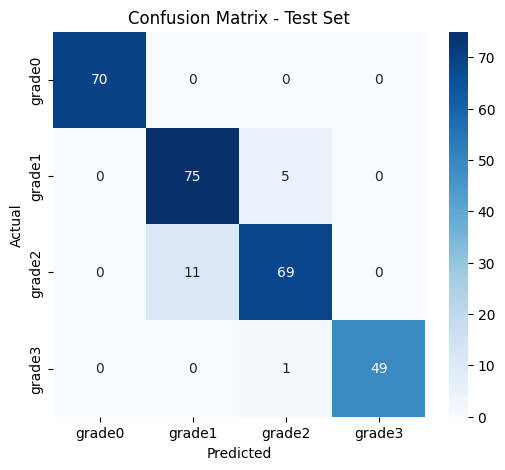

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',   # 👈 Blue color map
    xticklabels=test_dataset.classes,
    yticklabels=test_dataset.classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Test Set")
plt.show()


In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
# Convert labels to one-hot format
n_classes = len(test_dataset.classes)

all_labels_bin = label_binarize(all_labels, classes=[0,1,2,3])


In [ ]:
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(all_labels_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])


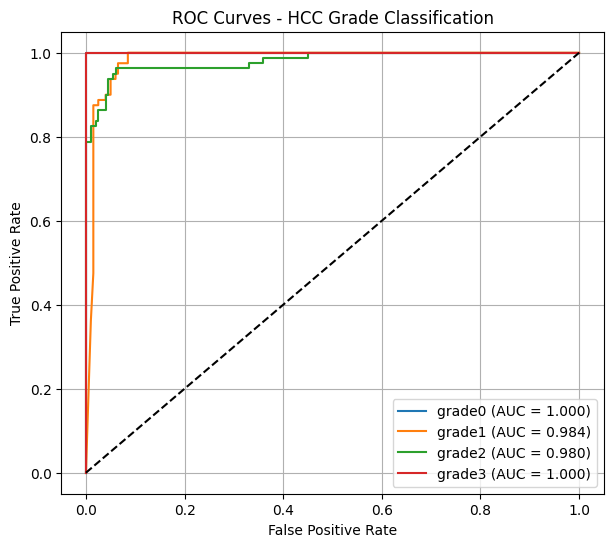

In [ ]:
plt.figure(figsize=(7,6))

for i in range(n_classes):
    plt.plot(
        fpr[i],
        tpr[i],
        label=f"{test_dataset.classes[i]} (AUC = {roc_auc[i]:.3f})"
    )

# Diagonal reference line
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - HCC Grade Classification")
plt.legend()
plt.grid()
plt.show()


In [ ]:
!pip install grad-cam


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 53.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44285 sha256=f90326863a53f1503b5ed3fcf35eac54ab778a994864befbb1d4a0c647a5a319
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import torch
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget


In [ ]:
target_layer = model.blocks[-1].norm1


In [ ]:
image, label = test_dataset[0]

input_tensor = image.unsqueeze(0).cuda()


In [ ]:
# Convert tensor back to numpy image for overlay
img_np = image.permute(1,2,0).cpu().numpy()
img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())


In [ ]:
# Convert tensor back to numpy image for overlay
img_np = image.permute(1,2,0).cpu().numpy()
img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())


In [ ]:
def reshape_transform(tensor, height=14, width=14):
    # Remove CLS token
    tensor = tensor[:, 1:, :]

    # Reshape to (B, C, H, W)
    tensor = tensor.reshape(tensor.size(0), height, width, tensor.size(2))
    tensor = tensor.permute(0, 3, 1, 2)
    return tensor


In [ ]:
target_layer = model.blocks[-1].norm1


In [ ]:
cam = GradCAM(
    model=model,
    target_layers=[target_layer],
    reshape_transform=reshape_transform
)


In [ ]:
image, label = test_dataset[0]
input_tensor = image.unsqueeze(0).cuda()

targets = [ClassifierOutputTarget(label)]

grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
grayscale_cam = grayscale_cam[0]


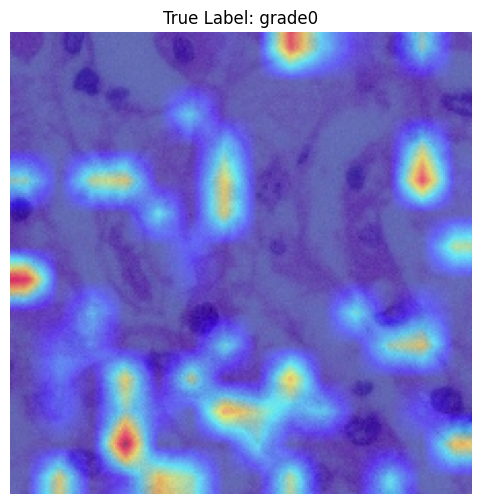

In [ ]:
img_np = image.permute(1,2,0).cpu().numpy()
img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

plt.figure(figsize=(6,6))
plt.imshow(visualization)
plt.title(f"True Label: {test_dataset.classes[label]}")
plt.axis("off")
plt.show()


In [ ]:
def reshape_transform(tensor, height=14, width=14):
    tensor = tensor[:, 1:, :]
    tensor = tensor.reshape(tensor.size(0), height, width, tensor.size(2))
    tensor = tensor.permute(0, 3, 1, 2)
    return tensor


In [ ]:
target_layer = model.blocks[-1].norm1


In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

cam = GradCAM(
    model=model,
    target_layers=[target_layer],
    reshape_transform=reshape_transform
)


In [ ]:
def visualize_gradcam(index):
    image, label = test_dataset[index]
    input_tensor = image.unsqueeze(0).cuda()

    model.eval()
    with torch.no_grad():
        output = model(input_tensor)
        pred = torch.argmax(output, dim=1).item()

    targets = [ClassifierOutputTarget(label)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

    img_np = image.permute(1,2,0).cpu().numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

    visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

    return img_np, visualization, label, pred


In [ ]:
examples = {}

model.eval()

for idx in range(len(test_dataset)):
    image, label = test_dataset[idx]
    input_tensor = image.unsqueeze(0).cuda()

    with torch.no_grad():
        output = model(input_tensor)
        pred = torch.argmax(output, dim=1).item()

    if pred == label and label not in examples:
        examples[label] = idx

    if len(examples) == 4:
        break

print("Selected indices:", examples)


Selected indices: {0: 0, 1: 70, 2: 150, 3: 230}


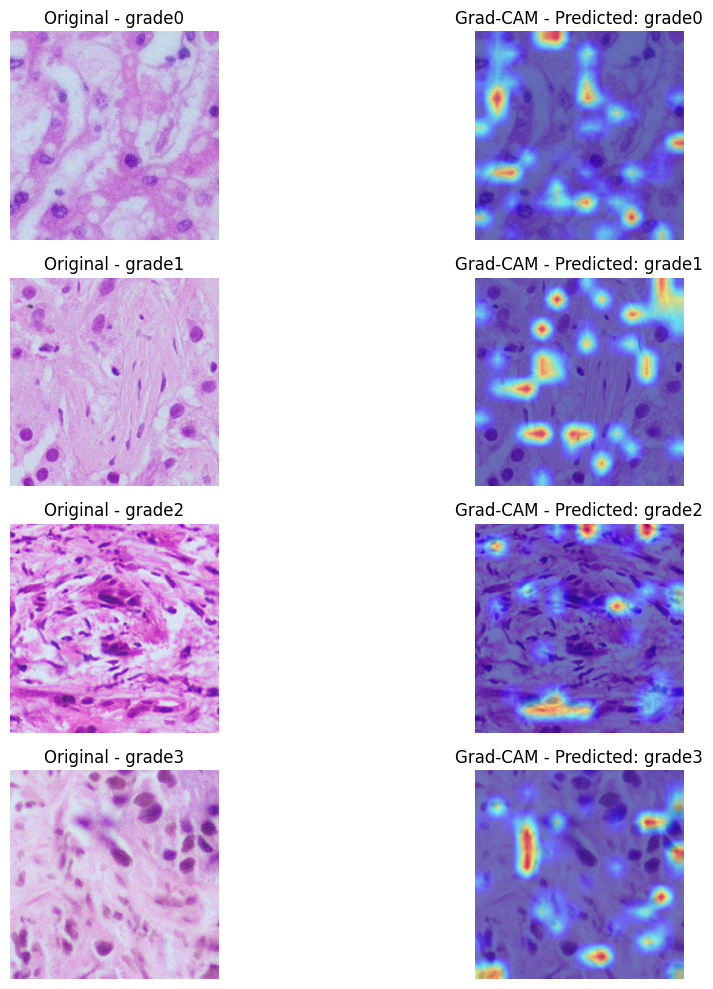

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))

for i, grade in enumerate(sorted(examples.keys())):
    img_np, cam_img, label, pred = visualize_gradcam(examples[grade])

    # Original
    plt.subplot(4,2,2*i+1)
    plt.imshow(img_np)
    plt.title(f"Original - {test_dataset.classes[label]}")
    plt.axis("off")

    # Grad-CAM
    plt.subplot(4,2,2*i+2)
    plt.imshow(cam_img)
    plt.title(f"Grad-CAM - Predicted: {test_dataset.classes[pred]}")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
from torch.utils.data import ConcatDataset

train_full_dataset = ConcatDataset([train_dataset, val_dataset])
print("Total CV dataset size:", len(train_full_dataset))


Total CV dataset size: 2829


In [ ]:
import numpy as np

all_labels = []

for _, label in train_full_dataset:
    all_labels.append(label)

all_labels = np.array(all_labels)


In [ ]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


In [ ]:
from torch.utils.data import Subset
import torch

fold_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(all_labels)), all_labels)):

    print(f"\n===== Fold {fold+1} =====")

    train_subset = Subset(train_full_dataset, train_idx)
    val_subset = Subset(train_full_dataset, val_idx)

    train_loader = DataLoader(train_subset, batch_size=16, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=16, shuffle=False)

    # Initialize new model for each fold
    model = timm.create_model(
        'vit_base_patch16_224',
        pretrained=True,
        num_classes=4
    ).cuda()

    # Freeze backbone initially
    for param in model.parameters():
        param.requires_grad = False
    for param in model.head.parameters():
        param.requires_grad = True

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.head.parameters(), lr=1e-3)

    # Train 5 epochs (for CV stage)
    epochs = 5
    for epoch in range(epochs):
        model.train()
        for images, labels in train_loader:
            images = images.cuda()
            labels = labels.cuda()

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    # Validation Accuracy
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.cuda()
            labels = labels.cuda()
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    print("Fold Accuracy:", val_acc)

    fold_results.append(val_acc)



===== Fold 1 =====
Fold Accuracy: 95.22968197879858

===== Fold 2 =====
Fold Accuracy: 94.69964664310955

===== Fold 3 =====
Fold Accuracy: 93.81625441696113

===== Fold 4 =====
Fold Accuracy: 93.28621908127208

===== Fold 5 =====
Fold Accuracy: 90.08849557522124


In [ ]:
import numpy as np

fold_results = np.array(fold_results)

mean_acc = np.mean(fold_results)
std_acc = np.std(fold_results)

print(f"Cross-Validation Accuracy: {mean_acc:.2f}% ± {std_acc:.2f}")


Cross-Validation Accuracy: 93.42% ± 1.80


In [ ]:
from torch.utils.data import ConcatDataset

full_dataset = ConcatDataset([train_dataset, val_dataset])
print("Total CV dataset size:", len(full_dataset))


Total CV dataset size: 2829


In [ ]:
import numpy as np

all_labels = []

for _, label in full_dataset:
    all_labels.append(label)

all_labels = np.array(all_labels)


In [ ]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Subset, DataLoader
from sklearn.metrics import roc_auc_score
import timm

fold_accuracies = []
fold_aucs = []

for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(all_labels)), all_labels)):

    print(f"\n===== Fold {fold+1} =====")

    train_subset = Subset(full_dataset, train_idx)
    val_subset = Subset(full_dataset, val_idx)

    train_loader = DataLoader(train_subset, batch_size=16, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=16, shuffle=False)

    # Initialize fresh model
    model = timm.create_model(
        'vit_base_patch16_224',
        pretrained=True,
        num_classes=4
    ).cuda()

    # Freeze backbone initially
    for param in model.parameters():
        param.requires_grad = False
    for param in model.head.parameters():
        param.requires_grad = True

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.head.parameters(), lr=1e-3)

    # ---- Training (5 epochs for CV stage) ----
    epochs = 5
    for epoch in range(epochs):
        model.train()
        for images, labels in train_loader:
            images = images.cuda()
            labels = labels.cuda()

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    # ---- Validation Evaluation ----
    model.eval()
    correct = 0
    total = 0

    all_probs = []
    all_val_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.cuda()
            labels = labels.cuda()

            outputs = model(images)
            probs = F.softmax(outputs, dim=1)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_probs.extend(probs.cpu().numpy())
            all_val_labels.extend(labels.cpu().numpy())

    val_acc = 100 * correct / total
    fold_accuracies.append(val_acc)

    all_probs = np.array(all_probs)
    all_val_labels = np.array(all_val_labels)

    val_auc = roc_auc_score(
        all_val_labels,
        all_probs,
        multi_class='ovr',
        average='macro'
    )

    fold_aucs.append(val_auc)

    print(f"Fold Accuracy: {val_acc:.2f}%")
    print(f"Fold ROC-AUC: {val_auc:.4f}")



===== Fold 1 =====
Fold Accuracy: 94.52%
Fold ROC-AUC: 0.9946

===== Fold 2 =====
Fold Accuracy: 92.23%
Fold ROC-AUC: 0.9927

===== Fold 3 =====
Fold Accuracy: 94.70%
Fold ROC-AUC: 0.9939

===== Fold 4 =====
Fold Accuracy: 95.05%
Fold ROC-AUC: 0.9949

===== Fold 5 =====
Fold Accuracy: 93.10%
Fold ROC-AUC: 0.9921


In [ ]:
fold_accuracies = np.array(fold_accuracies)
fold_aucs = np.array(fold_aucs)

mean_acc = np.mean(fold_accuracies)
std_acc = np.std(fold_accuracies)

mean_auc = np.mean(fold_aucs)
std_auc = np.std(fold_aucs)

print("\n===== Final Cross-Validation Results =====")
print(f"Accuracy: {mean_acc:.2f}% ± {std_acc:.2f}")
print(f"ROC-AUC: {mean_auc:.4f} ± {std_auc:.4f}")



===== Final Cross-Validation Results =====
Accuracy: 93.92% ± 1.08
ROC-AUC: 0.9936 ± 0.0011


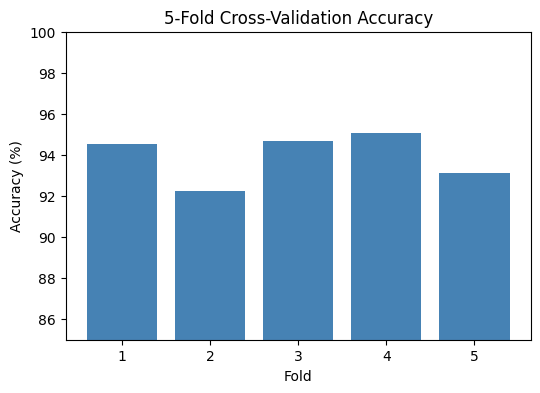

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

folds = np.arange(1, 6)

plt.figure(figsize=(6,4))
plt.bar(folds, fold_accuracies, color='steelblue')

plt.xlabel("Fold")
plt.ylabel("Accuracy (%)")
plt.title("5-Fold Cross-Validation Accuracy")
plt.xticks(folds)
plt.ylim(85, 100)
plt.show()


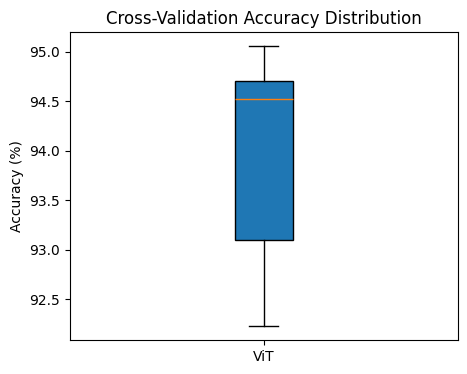

In [ ]:
plt.figure(figsize=(5,4))
plt.boxplot(fold_accuracies, patch_artist=True)

plt.ylabel("Accuracy (%)")
plt.title("Cross-Validation Accuracy Distribution")
plt.xticks([1], ["ViT"])
plt.show()


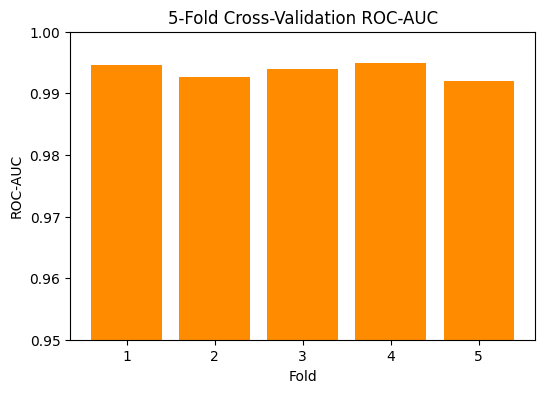

In [ ]:
plt.figure(figsize=(6,4))
plt.bar(folds, fold_aucs, color='darkorange')

plt.xlabel("Fold")
plt.ylabel("ROC-AUC")
plt.title("5-Fold Cross-Validation ROC-AUC")
plt.xticks(folds)
plt.ylim(0.95, 1.0)
plt.show()


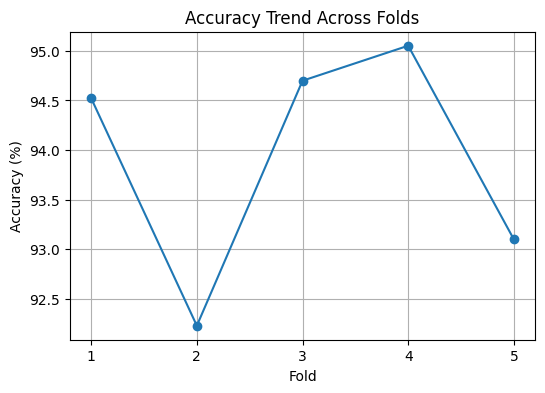

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(folds, fold_accuracies, marker='o')

plt.xlabel("Fold")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Trend Across Folds")
plt.xticks(folds)
plt.grid()
plt.show()



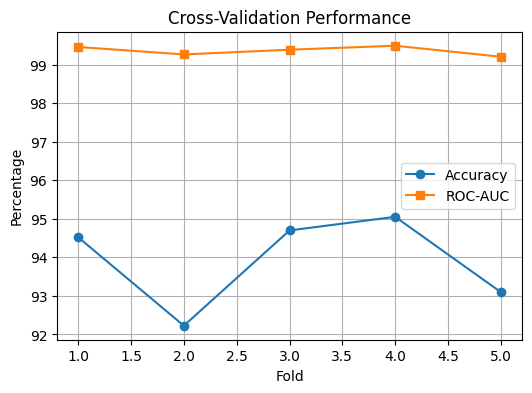

In [ ]:
plt.figure(figsize=(6,4))

plt.plot(folds, fold_accuracies, marker='o', label='Accuracy')
plt.plot(folds, fold_aucs * 100, marker='s', label='ROC-AUC')

plt.xlabel("Fold")
plt.ylabel("Percentage")
plt.title("Cross-Validation Performance")
plt.legend()
plt.grid()
plt.show()


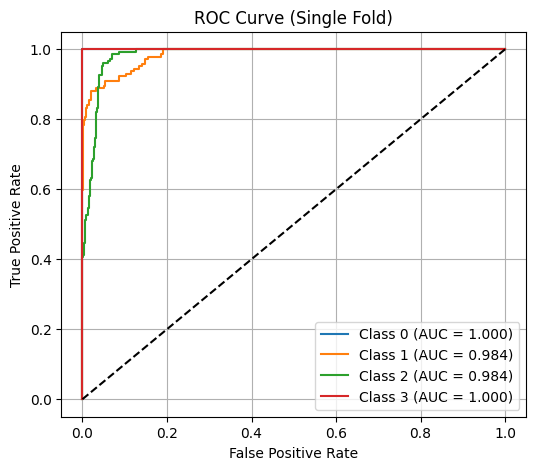

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

n_classes = 4

labels_bin = label_binarize(all_val_labels, classes=[0,1,2,3])

plt.figure(figsize=(6,5))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(labels_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Single Fold)")
plt.legend()
plt.grid()
plt.show()


In [ ]:
from sklearn.metrics import confusion_matrix

fold_conf_matrices = []


In [ ]:
model.eval()
all_preds = []
all_val_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.cuda()
        labels = labels.cuda()

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_val_labels.extend(labels.cpu().numpy())

# Confusion matrix for this fold
cm = confusion_matrix(all_val_labels, all_preds)
fold_conf_matrices.append(cm)

print("Confusion Matrix:\n", cm)


Confusion Matrix:
 [[129   0   0   0]
 [  0 131  13   0]
 [  0  17 130   3]
 [  0   0   0 142]]


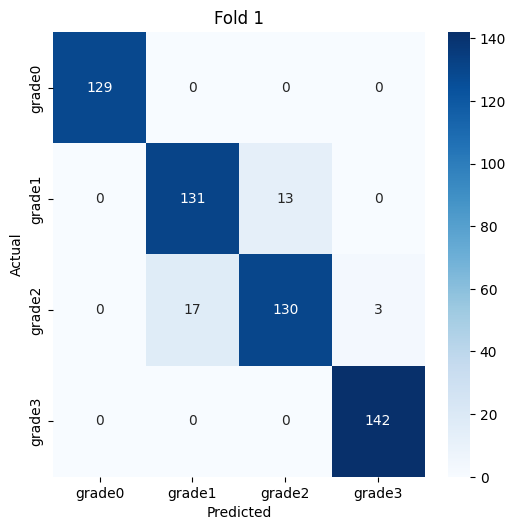

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

class_names = train_dataset.classes  # ['grade0', 'grade1', ...]

plt.figure(figsize=(15,10))

for i, cm in enumerate(fold_conf_matrices):
    plt.subplot(2,3,i+1)
    sns.heatmap(cm,
                annot=True,
                fmt='d',
                cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title(f"Fold {i+1}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

plt.tight_layout()
plt.show()
